In [1]:
import TimeTagger
import itertools
import numpy as np
from TimeTagger import TimeTaggerBase, Coincidence, Coincidences, CoincidenceTimestamp, FileReader, TimeTagStream, Correlation, Counter, DelayedChannel
import time
import csv 

tagger = TimeTagger.createTimeTagger()
#tagger.setHardwareBufferSize(536870912) # was 67108864(536870912)

#frequency_channel = 1 
#PPS_channel = 2 
# Define the hardware settings here, such as trigger level or dead time. 
for ch in [1, 2, 3, 4]:
    tagger.setTriggerLevel(ch, -0.3)

tagger.setInputDelay(-1, 0) #ps
tagger.setInputDelay(-2, 0)
tagger.setInputDelay(-3, 6200)
tagger.setInputDelay(-4, 6200)

ch = [-1, -2, -3, -4]
bw = 500_000        # trial = 500 ns [ps]

In [2]:
#Estimation of counts to displacement amplitude
def count_to_alpha(rates, bw):
    """
    rates : [CH1, CH2, CH3, CH4] count rates [Hz]
    bw    : trial width [ps]
    """
    T_trial = bw * 1e-12                 # ps -> s
    p = np.array(rates) * T_trial        # click probability / pixel

    mu_pixel = -np.log(1 - p)
    mu = np.sum(mu_pixel)
    alpha = np.sqrt(mu)

    print("Rates [Hz] =", rates)
    print("P click/pixel =", p)
    print(f"mu = {mu:.3f}")
    print(f"alpha = {alpha:.3f}")

    return alpha

rate = TimeTagger.Countrate(tagger, ch)
time.sleep(1)

rates = rate.getData()
for c, r in zip(ch, rates):
    print(f"CH{abs(c)}: {r:.0f} counts/s")

alpha = count_to_alpha(rates, bw)
print(alpha)

CH1: 513528 counts/s
CH2: 492191 counts/s
CH3: 507703 counts/s
CH4: 470957 counts/s
Rates [Hz] = [513528.06949899 492190.6364354  507702.94129708 470957.0632407 ]
P click/pixel = [0.25676403 0.24609532 0.25385147 0.23547853]
mu = 1.141
alpha = 1.068
1.0679732234137858


In [3]:
T = 30
bw = 500_000        # trial = 500 ns [ps]

T_ps = int(T * 1e12)
N_trial = T_ps // bw

N = np.zeros(5, dtype=int)
last_trial = None
last_mask = 0

def process(data):
    global last_trial, last_mask

    ts = np.asarray(data.getTimestamps())
    cs = np.asarray(data.getChannels())

    # Nothing in this buffer
    if len(ts) == 0:
        return

    # Which 2.2-us trial each tag belongs to
    trial = (ts - data.tStart) // bw

    # -1 -> 0001
    # -2 -> 0010
    # -3 -> 0100
    # -4 -> 1000
    bits = 1 << (-cs - 1)

    # Only complete acquisition trials
    good = (trial >= 0) & (trial < N_trial)
    trial = trial[good]
    bits = bits[good]

    if len(trial) == 0:
        return

    # Group tags belonging to the same trial
    starts = np.r_[0, np.where(np.diff(trial) != 0)[0] + 1]
    tr = trial[starts]
    masks = np.bitwise_or.reduceat(bits, starts)

    for ti, mask in zip(tr, masks):

        if last_trial is None:
            last_trial = ti
            last_mask = mask

        elif ti == last_trial:
            last_mask |= mask

        else:
            c = int(last_mask).bit_count()
            N[c] += 1

            last_trial = ti
            last_mask = mask


stream = TimeTagger.TimeTagStream(
    tagger,
    n_max_events=1_000_000,
    channels=ch
)

stream.stop()
stream.startFor(T_ps, clear=True)

total_tags = 0

while stream.isRunning():
    data = stream.getData()
    total_tags += data.size
    process(data)
    time.sleep(0.05)

# Remaining tags
data = stream.getData()
total_tags += data.size
process(data)

# Count final occupied trial
if last_trial is not None:
    c = int(last_mask).bit_count()
    N[c] += 1

# Empty trials
N[0] = N_trial - N[1:].sum()

P = N / N_trial

print("Total tags =", total_tags)
print("N_trial =", N_trial)
print("sum N =", N.sum())
print("sum P =", P.sum())

for c in range(5):
    print(f"c={c}: N={N[c]:10d}, P={P[c]:.6e}")

Total tags = 59562532
N_trial = 60000000
sum N = 60000000
sum P = 0.9999999999999999
c=0: N=  21426129, P=3.571022e-01
c=1: N=  25167662, P=4.194610e-01
c=2: N=  11080966, P=1.846828e-01
c=3: N=   2166581, P=3.610968e-02
c=4: N=    158662, P=2.644367e-03


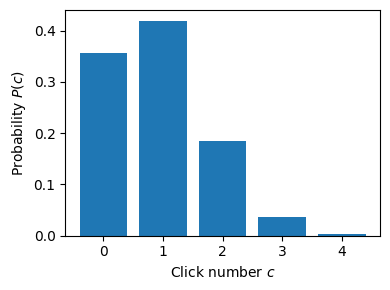

In [4]:
import matplotlib.pyplot as plt
import numpy as np

c = np.arange(5)

plt.figure(figsize=(4, 3))
plt.bar(c, P)

plt.xlabel("Click number $c$")
plt.ylabel("Probability $P(c)$")
plt.xticks(c)

plt.tight_layout()
plt.show()

In [5]:
mu_det = -np.log(P[0])
alpha_det = np.sqrt(mu_det)

print("mu_det =", mu_det)
print("alpha_det =", alpha_det)

mu_det = 1.029733403677372
alpha_det = 1.0147578054281583


In [6]:

TimeTagger.freeTimeTagger(tagger)